# Producto
# Redes de Distribución y Rutas Óptimas
# Juan Antonio Pitol Meza
# Angel Emanuel Arellano Coloa

## Parte A. Modelado de la red de distribución

Se crea un grafo dirigido para representar las rutas de una red de distribución. 
El Centro Principal funciona como origen y se conecta con los almacenes y puntos de entrega.
Cada ruta tiene un peso que representa la distancia en kilómetros y una capacidad máxima expresada en toneladas.

In [1]:
# Importamos las librerías

import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Creamos el grafo dirigido

grafo = nx.DiGraph()

# Agregamos las rutas con sus pesos
# El peso representa la distancia en kilómetros

grafo.add_weighted_edges_from([
    
    ("Centro Principal", "Almacen Norte", 8),
    ("Centro Principal", "Almacen Sur", 4),
    ("Centro Principal", "Almacen Este", 10),

    ("Almacen Norte", "Entrega A", 12),
    ("Almacen Norte", "Entrega B", 14),
    ("Almacen Norte", "Almacen Este", 3),

    ("Almacen Sur", "Entrega C", 12),
    ("Almacen Sur", "Entrega D", 13),
    ("Almacen Sur", "Almacen Este", 3),

    ("Almacen Este", "Entrega E", 8),
    ("Almacen Este", "Entrega B", 9),
    ("Almacen Este", "Entrega D", 10)
])

In [3]:
# Agregamos la capacidad máxima de cada ruta en toneladas

capacidades = {

    ("Centro Principal", "Almacen Norte"): 10,
    ("Centro Principal", "Almacen Sur"): 8,
    ("Centro Principal", "Almacen Este"): 6,

    ("Almacen Norte", "Entrega A"): 7,
    ("Almacen Norte", "Entrega B"): 5,
    ("Almacen Norte", "Almacen Este"): 8,

    ("Almacen Sur", "Entrega C"): 8,
    ("Almacen Sur", "Entrega D"): 6,
    ("Almacen Sur", "Almacen Este"): 7,

    ("Almacen Este", "Entrega E"): 9,
    ("Almacen Este", "Entrega B"): 6,
    ("Almacen Este", "Entrega D"): 5
}

nx.set_edge_attributes(
    grafo,
    capacidades,
    "capacidad_maxima"
)

In [4]:
# Guardamos también el peso con el nombre "peso"

for origen, destino, datos in grafo.edges(data=True):
    datos["peso"] = datos["weight"]

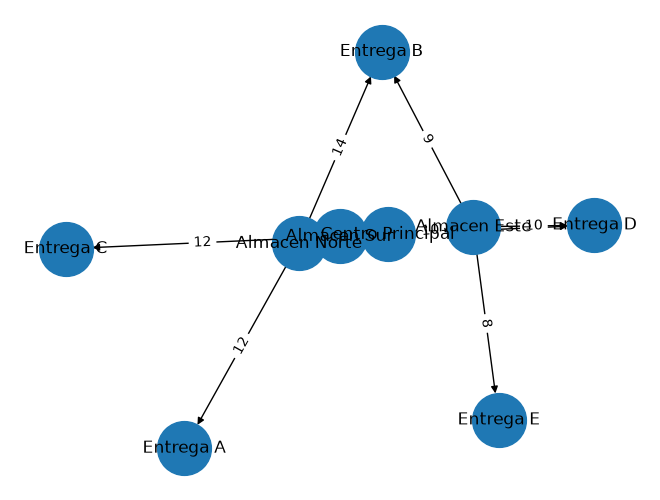

In [5]:
# Imprimimos el grafo
pos = nx.spring_layout(grafo, seed=10)

nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=1500,
    arrows=True
)

labels = nx.get_edge_attributes(grafo, "weight")

nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)

plt.show()

### Parte B. Verificación mediante lógica proposicional

# Para determinar si el despacho puede realizarse se utilizan cuatro proposiciones.

- **P:** El vehículo tiene mantenimiento preventivo al día.
- **Q:** La carga no excede la capacidad límite de la ruta.
- **R:** Las condiciones climáticas son favorables.
- **S:** La ruta está autorizada para el despacho.
La autorización depende de que se cumplan las condiciones P, Q y R.

In [6]:
# Datos del despacho

carga = 5

# Capacidad límite establecida para el despacho
capacidad_limite_ruta = 6

In [7]:
# Proposiciones lógicas

# P: El vehículo tiene mantenimiento preventivo al día
P = True

# Q: La carga no excede la capacidad límite de la ruta
Q = carga <= capacidad_limite_ruta

# R: Las condiciones climáticas son favorables
R = True

In [8]:
# Regla de inferencia
# (P AND Q AND R) => S

S = P and Q and R

In [9]:
print("P - Mantenimiento al dia:", P)
print("Q - Carga permitida:", Q)
print("R - Clima favorable:", R)
print("S - Ruta autorizada:", S)

P - Mantenimiento al dia: True
Q - Carga permitida: True
R - Clima favorable: True
S - Ruta autorizada: True


In [10]:
# Mensajes automáticos del sistema

if S == True:
    print("DESPACHO AUTORIZADO")
    print("Todas las condiciones se cumplen.")
    print("Se pueden ejecutar los algoritmos de búsqueda.")

else:
    print("DESPACHO BLOQUEADO")
    print("El sistema detectó una condición que impide el despacho.")

    if P == False:
        print("Motivo: El vehículo no tiene el mantenimiento al día.")

    if Q == False:
        print("Motivo: La carga excede la capacidad permitida.")

    if R == False:
        print("Motivo: Las condiciones climáticas no son favorables.")

DESPACHO AUTORIZADO
Todas las condiciones se cumplen.
Se pueden ejecutar los algoritmos de búsqueda.


In [11]:
regla_inferencia = (not (P and Q and R)) or S

print("La regla (P ∧ Q ∧ R) => S es:", regla_inferencia)

La regla (P ∧ Q ∧ R) => S es: True


## Parte C. Algoritmos de búsqueda

Para buscar una ruta desde el Centro Principal hasta un punto de entrega se utilizan los algoritmos BFS y UCS.

BFS realiza la búsqueda por niveles, mientras que UCS considera el costo acumulado de las rutas.

En ambos algoritmos también se verifica que cada conexión tenga la capacidad suficiente para transportar la carga.

In [12]:
# Calculamos el costo de una ruta

def costo_ruta(grafo, ruta):
    
    costo = 0
    
    for i in range(len(ruta) - 1):
        
        costo += grafo[ruta[i]][ruta[i + 1]]["peso"]
    
    return costo

In [13]:
# Algoritmo BFS - Busqueda en Anchura

def bfs(grafo, inicio, objetivo, carga):
    
    cola = [[inicio]]
    
    visitados = []
    
    while cola:
        
        camino = cola.pop(0)
        
        nodo = camino[-1]
        
        if nodo not in visitados:
            
            visitados.append(nodo)
            
            # Verificamos si llegamos al destino
            
            if nodo == objetivo:
                
                return camino, visitados
            
            # Revisamos los nodos vecinos
            
            for vecino in grafo.successors(nodo):
                
                capacidad = grafo[nodo][vecino]["capacidad_maxima"]
                
                # Solo usamos la ruta si soporta la carga
                
                if vecino not in visitados and carga <= capacidad:
                    
                    nuevo_camino = list(camino)
                    
                    nuevo_camino.append(vecino)
                    
                    cola.append(nuevo_camino)
    
    return None, visitados

### Búsqueda en Anchura (BFS)

BFS explora primero los nodos más cercanos al origen por cantidad de conexiones. 
El algoritmo continúa hasta encontrar el destino y solamente utiliza las rutas que soportan la carga indicada.

### Costo Uniforme (UCS)

UCS ordena las opciones de acuerdo con el costo acumulado. De esta manera, primero analiza las rutas que tienen un menor costo total hasta 
encontrar el destino.

In [14]:
# Algoritmo de Costo Uniforme - UCS

def ucs(grafo, inicio, objetivo, carga):
    
    cola = [(0, inicio, [inicio])]
    
    visitados = []
    
    while cola:
        
        # Ordenamos por el menor costo
        
        cola.sort(key=lambda x: x[0])
        
        costo_actual, nodo, camino = cola.pop(0)
        
        if nodo in visitados:
            continue
        
        visitados.append(nodo)
        
        # Verificamos si encontramos el destino
        
        if nodo == objetivo:
            
            return camino, visitados, costo_actual
        
        # Revisamos los vecinos
        
        for vecino in grafo.successors(nodo):
            
            capacidad = grafo[nodo][vecino]["capacidad_maxima"]
            
            # La ruta debe soportar la carga
            
            if vecino not in visitados and carga <= capacidad:
                
                nuevo_costo = (
                    costo_actual
                    + grafo[nodo][vecino]["peso"]
                )
                
                nuevo_camino = list(camino)
                
                nuevo_camino.append(vecino)
                
                cola.append(
                    (
                        nuevo_costo,
                        vecino,
                        nuevo_camino
                    )
                )
    
    return None, visitados, None

## Ejecución de las búsquedas

Se utilizará el Centro Principal como origen y Entrega E como destino.
Si la proposición S es falsa, el despacho se bloquea. Si S es verdadera, se ejecutan BFS y UCS para comparar sus resultados.

In [15]:
# Definimos origen y destino

origen = "Centro Principal"
destino = "Entrega B"

In [16]:
# Verificamos si el despacho está autorizado

if S == False:

    print("=== MENSAJE AUTOMÁTICO DEL SISTEMA ===")
    print("DESPACHO BLOQUEADO")
    print("No se pueden ejecutar los algoritmos de búsqueda.")

    # El sistema informa automáticamente la causa
    if P == False:
        print("Motivo: El vehículo no tiene el mantenimiento preventivo al día.")

    if Q == False:
        print("Motivo: La carga excede la capacidad permitida de la ruta.")

    if R == False:
        print("Motivo: Las condiciones climáticas no son favorables.")

else:

    print("=== MENSAJE AUTOMÁTICO DEL SISTEMA ===")
    print("DESPACHO AUTORIZADO")
    print("Todas las condiciones operativas se cumplen.")
    print("Iniciando búsqueda de rutas...")


    # --------------------------
    # BÚSQUEDA EN ANCHURA - BFS
    # --------------------------

    print("\n--------------------------")
    print("BUSQUEDA EN ANCHURA - BFS")
    print("--------------------------")

    ruta_bfs, visitados_bfs = bfs(
        grafo,
        origen,
        destino,
        carga
    )

    if ruta_bfs != None:

        costo_bfs = costo_ruta(
            grafo,
            ruta_bfs
        )

        print("Ruta encontrada:", ruta_bfs)
        print("Nodos visitados:", visitados_bfs)
        print("Cantidad de nodos visitados:", len(visitados_bfs))
        print("Costo total:", costo_bfs, "km")

        print("\nMENSAJE AUTOMÁTICO:")
        print("BFS encontró una ruta disponible para realizar el despacho.")

    else:

        print("No existe una ruta disponible.")

        print("\nMENSAJE AUTOMÁTICO:")
        print("BFS no encontró una ruta que cumpla con las condiciones.")


    # --------------------------
    # COSTO UNIFORME - UCS
    # --------------------------

    print("\n--------------------------")
    print("COSTO UNIFORME - UCS")
    print("--------------------------")

    ruta_ucs, visitados_ucs, costo_ucs = ucs(
        grafo,
        origen,
        destino,
        carga
    )

    if ruta_ucs != None:

        print("Ruta encontrada:", ruta_ucs)
        print("Nodos visitados:", visitados_ucs)
        print("Cantidad de nodos visitados:", len(visitados_ucs))
        print("Costo total:", costo_ucs, "km")

        print("\nMENSAJE AUTOMÁTICO:")
        print("UCS encontró una ruta disponible para realizar el despacho.")

    else:

        print("No existe una ruta disponible.")

        print("\nMENSAJE AUTOMÁTICO:")
        print("UCS no encontró una ruta que cumpla con las condiciones.")

=== MENSAJE AUTOMÁTICO DEL SISTEMA ===
DESPACHO AUTORIZADO
Todas las condiciones operativas se cumplen.
Iniciando búsqueda de rutas...

--------------------------
BUSQUEDA EN ANCHURA - BFS
--------------------------
Ruta encontrada: ['Centro Principal', 'Almacen Norte', 'Entrega B']
Nodos visitados: ['Centro Principal', 'Almacen Norte', 'Almacen Sur', 'Almacen Este', 'Entrega A', 'Entrega B']
Cantidad de nodos visitados: 6
Costo total: 22 km

MENSAJE AUTOMÁTICO:
BFS encontró una ruta disponible para realizar el despacho.

--------------------------
COSTO UNIFORME - UCS
--------------------------
Ruta encontrada: ['Centro Principal', 'Almacen Sur', 'Almacen Este', 'Entrega B']
Nodos visitados: ['Centro Principal', 'Almacen Sur', 'Almacen Este', 'Almacen Norte', 'Entrega E', 'Entrega C', 'Entrega B']
Cantidad de nodos visitados: 7
Costo total: 16 km

MENSAJE AUTOMÁTICO:
UCS encontró una ruta disponible para realizar el despacho.


In [17]:
# Comparamos los resultados

if S == True and ruta_bfs != None and ruta_ucs != None:
    
    print("\n==========================")
    print("COMPARACION DE RESULTADOS")
    print("==========================")
    
    print("BFS:")
    print("Ruta:", ruta_bfs)
    print("Costo:", costo_bfs, "km")
    print("Nodos visitados:", len(visitados_bfs))
    
    print("\nUCS:")
    print("Ruta:", ruta_ucs)
    print("Costo:", costo_ucs, "km")
    print("Nodos visitados:", len(visitados_ucs))
    
    
    if costo_ucs < costo_bfs:

        print("\n=== RECOMENDACIÓN AUTOMÁTICA ===")
        print("El sistema recomienda utilizar la ruta encontrada por UCS.")
        print("Ruta recomendada:", ruta_ucs)
        print("Costo mínimo:", costo_ucs, "km")

    elif costo_bfs < costo_ucs:

        print("\n=== RECOMENDACIÓN AUTOMÁTICA ===")
        print("El sistema recomienda utilizar la ruta encontrada por BFS.")
        print("Ruta recomendada:", ruta_bfs)
        print("Costo mínimo:", costo_bfs, "km")

    else:

        print("\n=== RECOMENDACIÓN AUTOMÁTICA ===")
        print("Ambos algoritmos encontraron rutas con el mismo costo.")


COMPARACION DE RESULTADOS
BFS:
Ruta: ['Centro Principal', 'Almacen Norte', 'Entrega B']
Costo: 22 km
Nodos visitados: 6

UCS:
Ruta: ['Centro Principal', 'Almacen Sur', 'Almacen Este', 'Entrega B']
Costo: 16 km
Nodos visitados: 7

=== RECOMENDACIÓN AUTOMÁTICA ===
El sistema recomienda utilizar la ruta encontrada por UCS.
Ruta recomendada: ['Centro Principal', 'Almacen Sur', 'Almacen Este', 'Entrega B']
Costo mínimo: 16 km
